In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ssefcca_functions as sfc

In [2]:
def ai(c,h,o):
    # return (1+c-o-s-0.5*h) / (c-o-s-n)
    # return (1+c-o-0.5*h) / (c-o)
    return (1/(1-oc)) * (c_inv + 1 - oc - 0.5*hc)

In [ ]:
oc_lim = (0,1.5)
hc_lim = (0,2)

C = (1,90)
H = (4,200)
O = (0,26)
N = (0,2)
S = (0,1)


In [4]:
cc, hh, oo, = np.meshgrid(
    np.arange(C[0], C[1]+1, 1),
    np.arange(H[0], H[1]+1, 1),
    np.arange(O[0], O[1]+1, 1),
    # np.arange(N[0], N[1]+1, 1),
    # np.arange(S[0], S[1]+1, 1),
    )

cc = cc.flatten()
hh = hh.flatten()
oo = oo.flatten()
# nn = nn.flatten()
# ss = ss.flatten()

grid = np.vstack((cc,hh,oo)).T


In [5]:
oc = oo/cc
hc = hh/cc
c_inv = 1 / cc
AI = ai(oc,hc,c_inv)

idx = np.where((np.abs(AI) != np.inf)&
               (oc>=oc_lim[0])&(oc<=oc_lim[1])&
               (hc>=hc_lim[0])&(hc<=hc_lim[1]))[0]

oc = oc[idx]
hc = hc[idx]
c_inv = c_inv[idx]
AI = AI[idx]


AI_class = {
    '\\mathrm{AI} \\leq 0.5': "#bbbbbb",
    '\\mathrm{AI} > 0.5': '#808080',
    '\\mathrm{AI} \\geq 0.67': '#000000',
}

ai_colours = []
for value in AI:
    if value <= 0.5:
        key='\\mathrm{AI} \\leq 0.5'
    elif value > 0.5:
        if value < 0.67:
            key='\\mathrm{AI} > 0.5'
        else:
            key='\\mathrm{AI} \\geq 0.67'

    ai_colours.append(AI_class[key])


C:\Users\s2017658\AppData\Local\Temp\ipykernel_9044\1147163577.py:4: RuntimeWarning: divide by zero encountered in divide
  return (1/(1-oc)) * (c_inv + 1 - oc - 0.5*hc)


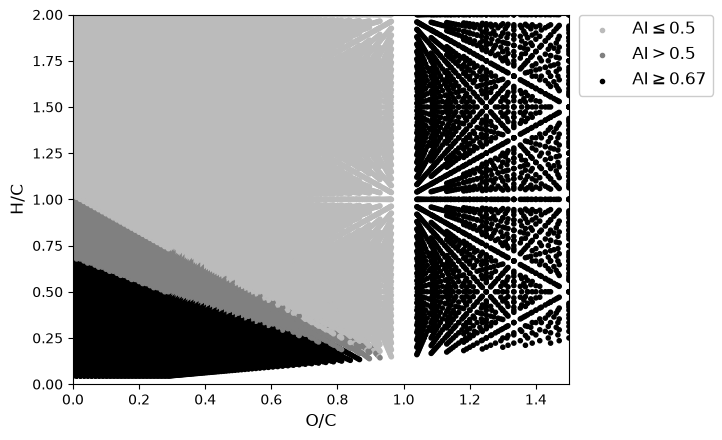

In [6]:
fig, ax = plt.subplots()

ax.scatter(oc,hc,c=ai_colours,marker='.')

for cl in AI_class:
    ax.scatter(None,None,c=AI_class[cl],label=f'${cl}$',marker='.')

ax.set_xlim(oc_lim)
ax.set_ylim(hc_lim)

ax.set_xlabel('O/C',fontsize=12)
ax.set_ylabel('H/C',fontsize=12)

ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)

fig.savefig('data/plots/van_krevelens/2d_aromaticity_index.png',dpi=300, facecolor = '#fff', bbox_inches='tight')

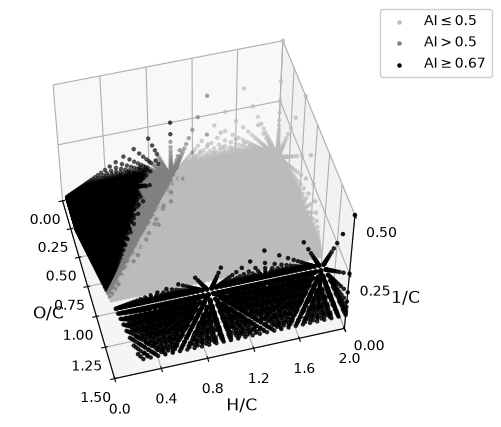

In [13]:
fig = plt.figure()

ax = fig.add_subplot(projection='3d')

ax.scatter(oc,hc,c_inv,c=ai_colours,marker='.')

ax.set_xlim(oc_lim)
ax.set_ylim(hc_lim)
ax.set_zlim(min(c_inv),max(c_inv))

ax.set_xlabel('O/C',fontsize=12)
ax.set_ylabel('H/C',fontsize=12)
ax.set_zlabel('1/C',fontsize=12)

sfc.set_axis_ticks(None, ax, axis='x', major_ticks_interval=.25,
                   minor_ticks_interval=None, rounding=1,
                   lower_lim=min(oc_lim), upper_lim=max(oc_lim))
sfc.set_axis_ticks(None, ax, axis='y', major_ticks_interval=.4,
                   minor_ticks_interval=None, rounding=1,
                   lower_lim=min(hc_lim), upper_lim=max(hc_lim))
sfc.set_axis_ticks(None, ax, axis='z', major_ticks_interval=.25,
                   minor_ticks_interval=None, rounding=1, 
                   lower_lim=min(c_inv), upper_lim=max(c_inv))

for cl in AI_class:
    ax.scatter(10,10,10,c=AI_class[cl],label=f'${cl}$',marker='.')

ax.legend(framealpha=1, bbox_to_anchor=(1, 1.05), loc='upper left', borderaxespad=0)

ax.view_init(elev=50, azim=-15)

fig.savefig('data/plots/van_krevelens/3d_aromaticity_index.png',dpi=300, facecolor = '#fff', bbox_inches='tight')